# NAÏVE BAYES ON A REVIEW CLASSIFICATION DATASET

## Import Libraries

In [9]:
import pandas as pd
import numpy as np
import re
import string
import pickle

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aruns\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aruns\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\aruns\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Load Dataset

In [10]:
df = pd.read_csv("output.csv")

df.columns = df.columns.str.strip()

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## Display First 10 Rows

In [11]:
df.head(10)

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
5,Now I am getting angry and I want my damn pho.,0
6,Honeslty it didn't taste THAT fresh.),0
7,The potatoes were like rubber and you could te...,0
8,The fries were great too.,1
9,A great touch.,1


## Dataset Information

In [12]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1000, 2)


In [13]:
print("Columns:")
print(df.columns)

Columns:
Index(['Review', 'Liked'], dtype='object')


In [14]:
print("Samples Per Class:")
print(df['Liked'].value_counts())

Samples Per Class:
Liked
1    500
0    500
Name: count, dtype: int64


In [15]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Review    0
Liked     0
dtype: int64


## Review Length Distribution

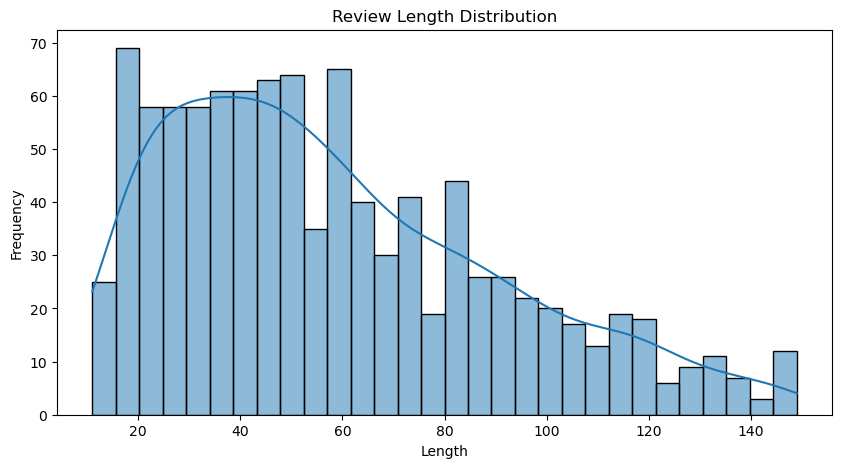

In [16]:
df['review_length'] = df['Review'].apply(len)

plt.figure(figsize=(10,5))

sns.histplot(df['review_length'], bins=30, kde=True)

plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

## Text Cleaning Function

In [17]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenize
    words = text.split()

    # remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

## Apply Cleaning

In [18]:
df['cleaned_review'] = df['Review'].apply(clean_text)

df[['Review', 'cleaned_review']].head()

,Review,cleaned_review
0,Wow... Loved this place.,wow loved place
1,Crust is not good.,crust good
2,Not tasty and the texture was just nasty.,tasty texture nasty
3,Stopped by during the late May bank holiday of...,stopped late may bank holiday rick steve recom...
4,The selection on the menu was great and so wer...,selection menu great price


## Count Vectorizer

In [19]:
count_vectorizer = CountVectorizer(binary=True)

X_count = count_vectorizer.fit_transform(df['cleaned_review'])

print(X_count.shape)

(1000, 1809)


## TF-IDF Vectorizer

In [20]:
tfidf_vectorizer = TfidfVectorizer()

X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_review'])

print(X_tfidf.shape)

(1000, 1809)


## Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_count,df['Liked'],test_size=0.2,random_state=42)

In [22]:
X_train.shape

(800, 1809)

In [23]:
X_test.shape

(200, 1809)

## Train Bernoulli Naive Bayes

In [24]:
model = BernoulliNB()
model.fit(X_train, y_train)
print("Model Training Completed")

Model Training Completed


## Predictions

In [25]:
y_pred = model.predict(X_test)

## Accuracy Metrics

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.75
Precision: 0.75
Recall   : 0.7788461538461539
F1 Score : 0.7641509433962265


## Confusion Matrix

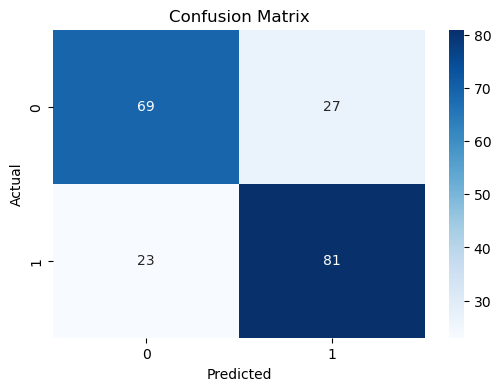

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Classification Report

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.72      0.73        96
           1       0.75      0.78      0.76       104

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



## Save PKL Files

In [29]:
with open("naive_bayes_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("vectorizer.pkl", "wb") as file:
    pickle.dump(count_vectorizer, file)

print("PKL files saved successfully!")

PKL files saved successfully!


## Predict New Reviews

In [30]:
sample_reviews = [
    "Amazing food and service",
    "Worst restaurant ever",
    "Very tasty food"
]

for review in sample_reviews:

    cleaned = clean_text(review)

    vectorized = count_vectorizer.transform([cleaned])

    prediction = model.predict(vectorized)[0]

    if prediction == 1:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print(f"\nReview: {review}")
    print(f"Prediction: {sentiment}")


Review: Amazing food and service
Prediction: Positive

Review: Worst restaurant ever
Prediction: Negative

Review: Very tasty food
Prediction: Positive
